# Tổng hợp thực nghiệm PhoBERT ABSA + LIME

Notebook này dùng để **show tổng quan project**, không đi sâu data exploration.

Nội dung:
- Kiểm tra dữ liệu đã xử lý
- Hiển thị kết quả PhoBERT
- Hiển thị kết quả baseline TF-IDF
- So sánh mô hình
- Hiển thị confusion matrix
- Test predict
- Test LIME


## 1. Import và cấu hình đường dẫn

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, HTML

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
sys.path.append(str(SRC_DIR))

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
PREDICTION_DIR = PROJECT_ROOT / "outputs" / "predictions"
MODEL_DIR = PROJECT_ROOT / "models" / "phobert_absa"

print("Project root:", PROJECT_ROOT)
print("Model exists:", MODEL_DIR.exists())
print("Processed data exists:", DATA_PROCESSED.exists())


Project root: f:\phobert-absa-lime-phone-review
Model exists: True
Processed data exists: True


## 2. Kiểm tra nhanh dữ liệu đã xử lý

In [2]:
files = {
    "train": DATA_PROCESSED / "train_absa.csv",
    "dev": DATA_PROCESSED / "dev_absa.csv",
    "test": DATA_PROCESSED / "test_absa.csv"
}

rows = []
for name, path in files.items():
    if path.exists():
        df = pd.read_csv(path)
        rows.append({
            "Tập dữ liệu": name,
            "Số dòng": len(df),
            "Số cột": len(df.columns),
            "Các cột": ", ".join(df.columns)
        })
    else:
        rows.append({
            "Tập dữ liệu": name,
            "Số dòng": "Không tìm thấy",
            "Số cột": "-",
            "Các cột": str(path)
        })

display(pd.DataFrame(rows))


,Tập dữ liệu,Số dòng,Số cột,Các cột
0,train,23872,4,"text, aspect, sentiment, label"
1,dev,3316,4,"text, aspect, sentiment, label"
2,test,6722,4,"text, aspect, sentiment, label"


## 3. Kết quả đánh giá PhoBERT

In [3]:
metrics_path = REPORT_DIR / "metrics.json"

if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    phobert_df = pd.DataFrame([
        {"Metric": k, "Value": v, "Percent": round(float(v) * 100, 2)}
        for k, v in metrics.items()
        if isinstance(v, (int, float))
    ])
    display(phobert_df)
else:
    print("Chưa có metrics.json. Hãy chạy: python src/evaluate.py hoặc python src/train.py")


,Metric,Value,Percent
0,accuracy,0.868789,86.88
1,macro_precision,0.833011,83.30
2,macro_recall,0.764199,76.42
3,macro_f1,0.786361,78.64
4,weighted_precision,0.862303,86.23
5,weighted_recall,0.868789,86.88
6,weighted_f1,0.860588,86.06


## 4. Kết quả baseline TF-IDF

In [4]:
baseline_path = REPORT_DIR / "baseline_comparison.csv"

if baseline_path.exists():
    baseline_df = pd.read_csv(baseline_path)
    display(baseline_df)
else:
    print("Chưa có baseline_comparison.csv. Hãy chạy: python src/baseline_tfidf.py")


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,tfidf_logistic_regression,0.781464,0.703619,0.737064,0.714436,0.806831,0.781464,0.790360
1,tfidf_linear_svm,0.803332,0.723799,0.724101,0.723590,0.802758,0.803332,0.802722


## 5. So sánh PhoBERT với baseline

,Model,Accuracy,Macro F1,Weighted F1
0,tfidf_logistic_regression,0.781464,0.714436,0.790360
1,tfidf_linear_svm,0.803332,0.723590,0.802722
2,PhoBERT,0.868789,0.786361,0.860588


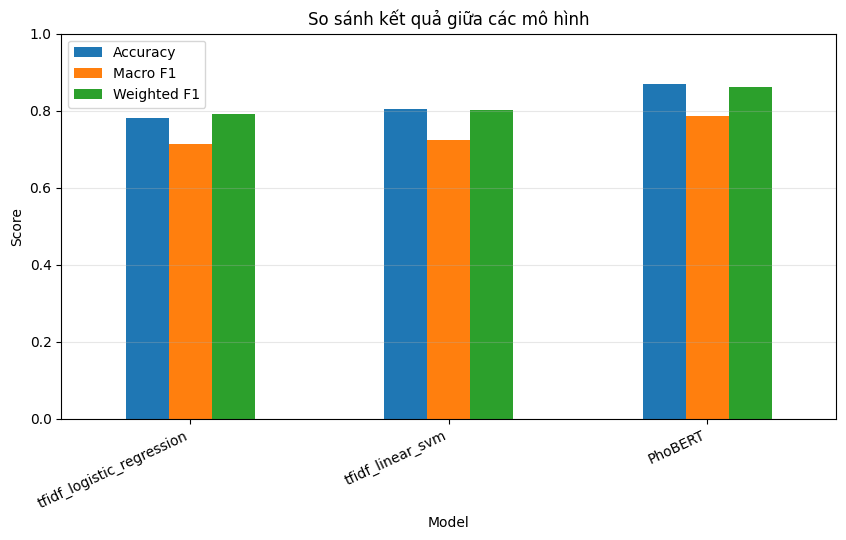

In [5]:
comparison_rows = []

if baseline_path.exists():
    baseline_df = pd.read_csv(baseline_path)
    for _, row in baseline_df.iterrows():
        comparison_rows.append({
            "Model": row["model"],
            "Accuracy": row.get("accuracy"),
            "Macro F1": row.get("macro_f1"),
            "Weighted F1": row.get("weighted_f1")
        })

if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    comparison_rows.append({
        "Model": "PhoBERT",
        "Accuracy": metrics.get("accuracy"),
        "Macro F1": metrics.get("macro_f1"),
        "Weighted F1": metrics.get("weighted_f1")
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

if not comparison_df.empty:
    plot_df = comparison_df.set_index("Model")[["Accuracy", "Macro F1", "Weighted F1"]]
    plot_df.plot(kind="bar", figsize=(10, 5))
    plt.title("So sánh kết quả giữa các mô hình")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=25, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.show()


## 6. Hiển thị confusion matrix

confusion_matrix.png


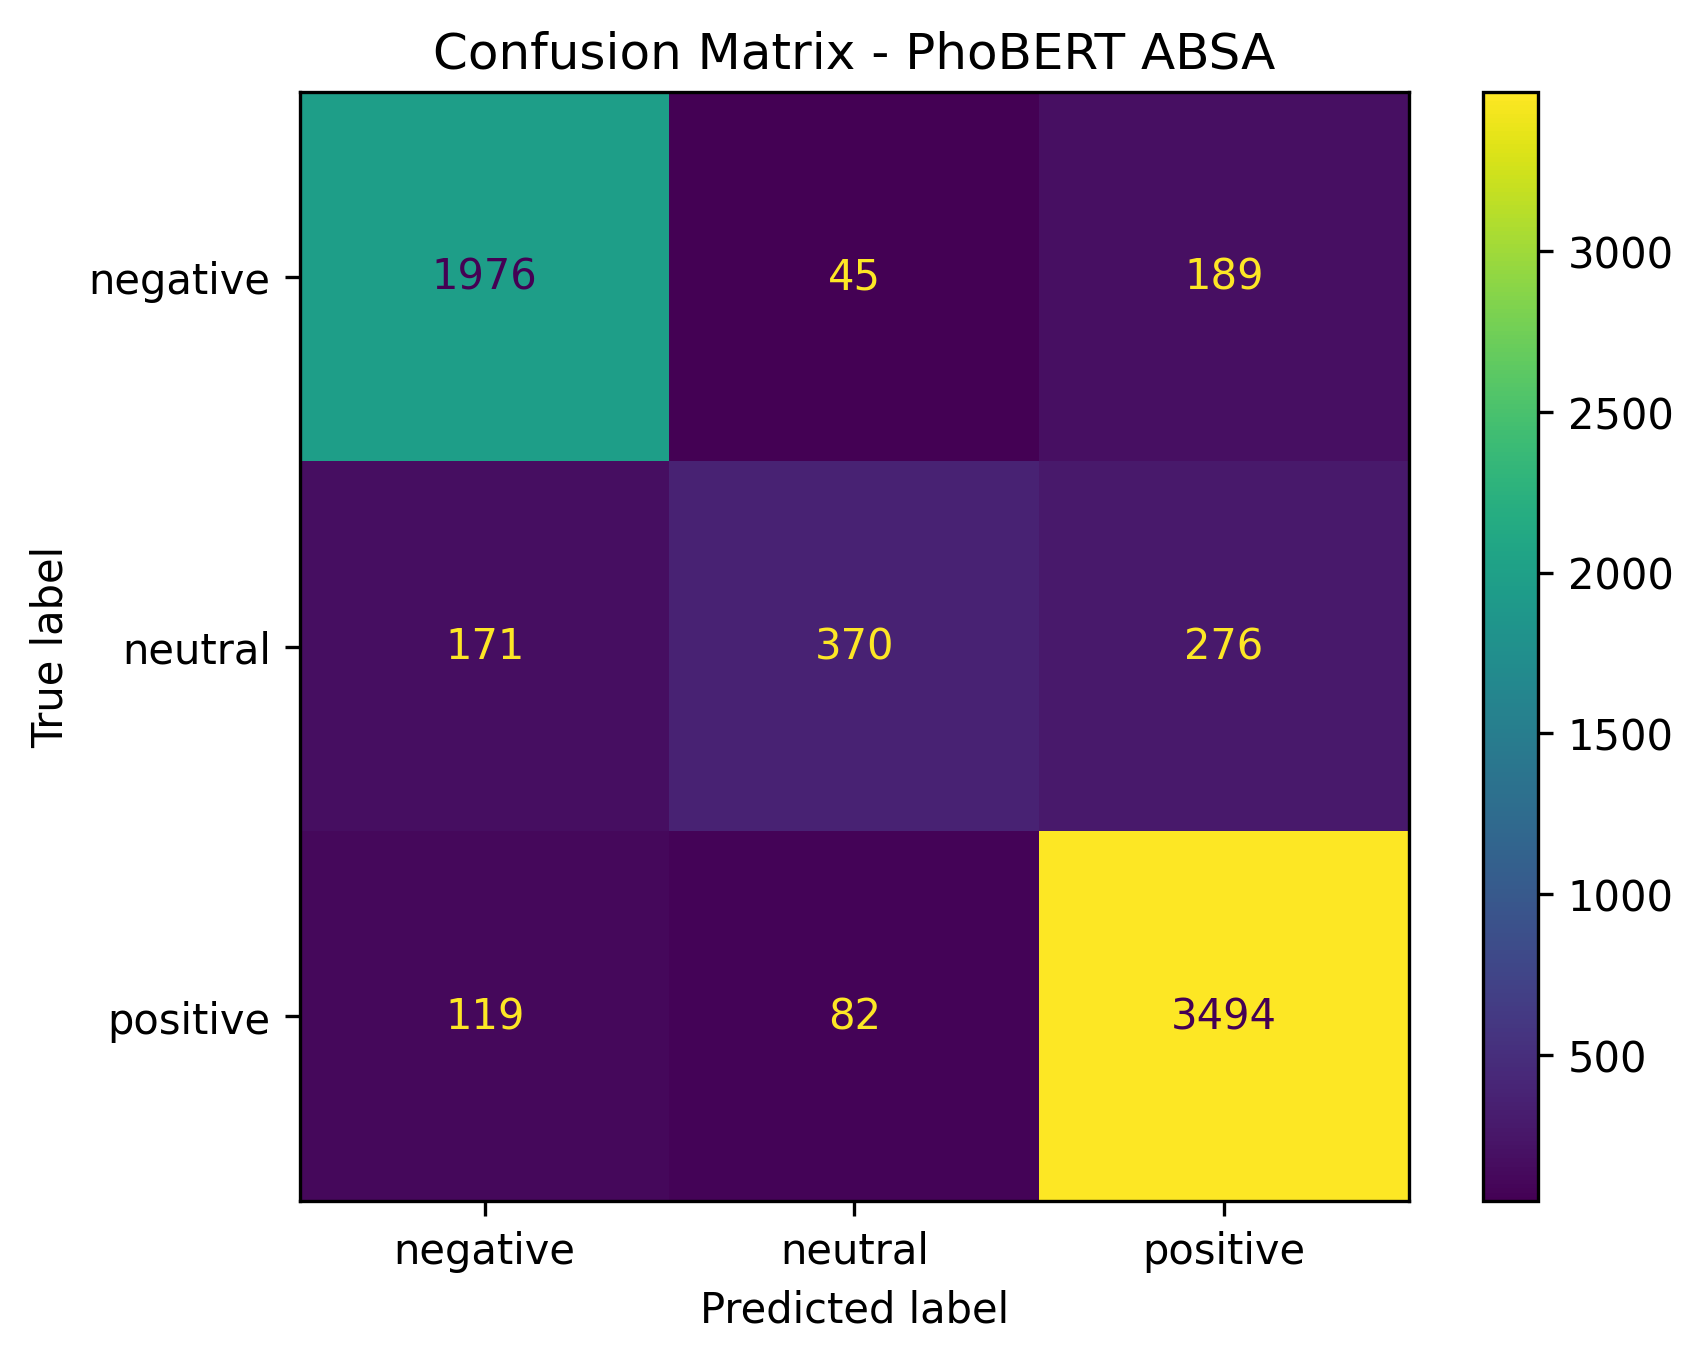

tfidf_logistic_regression_confusion_matrix.png


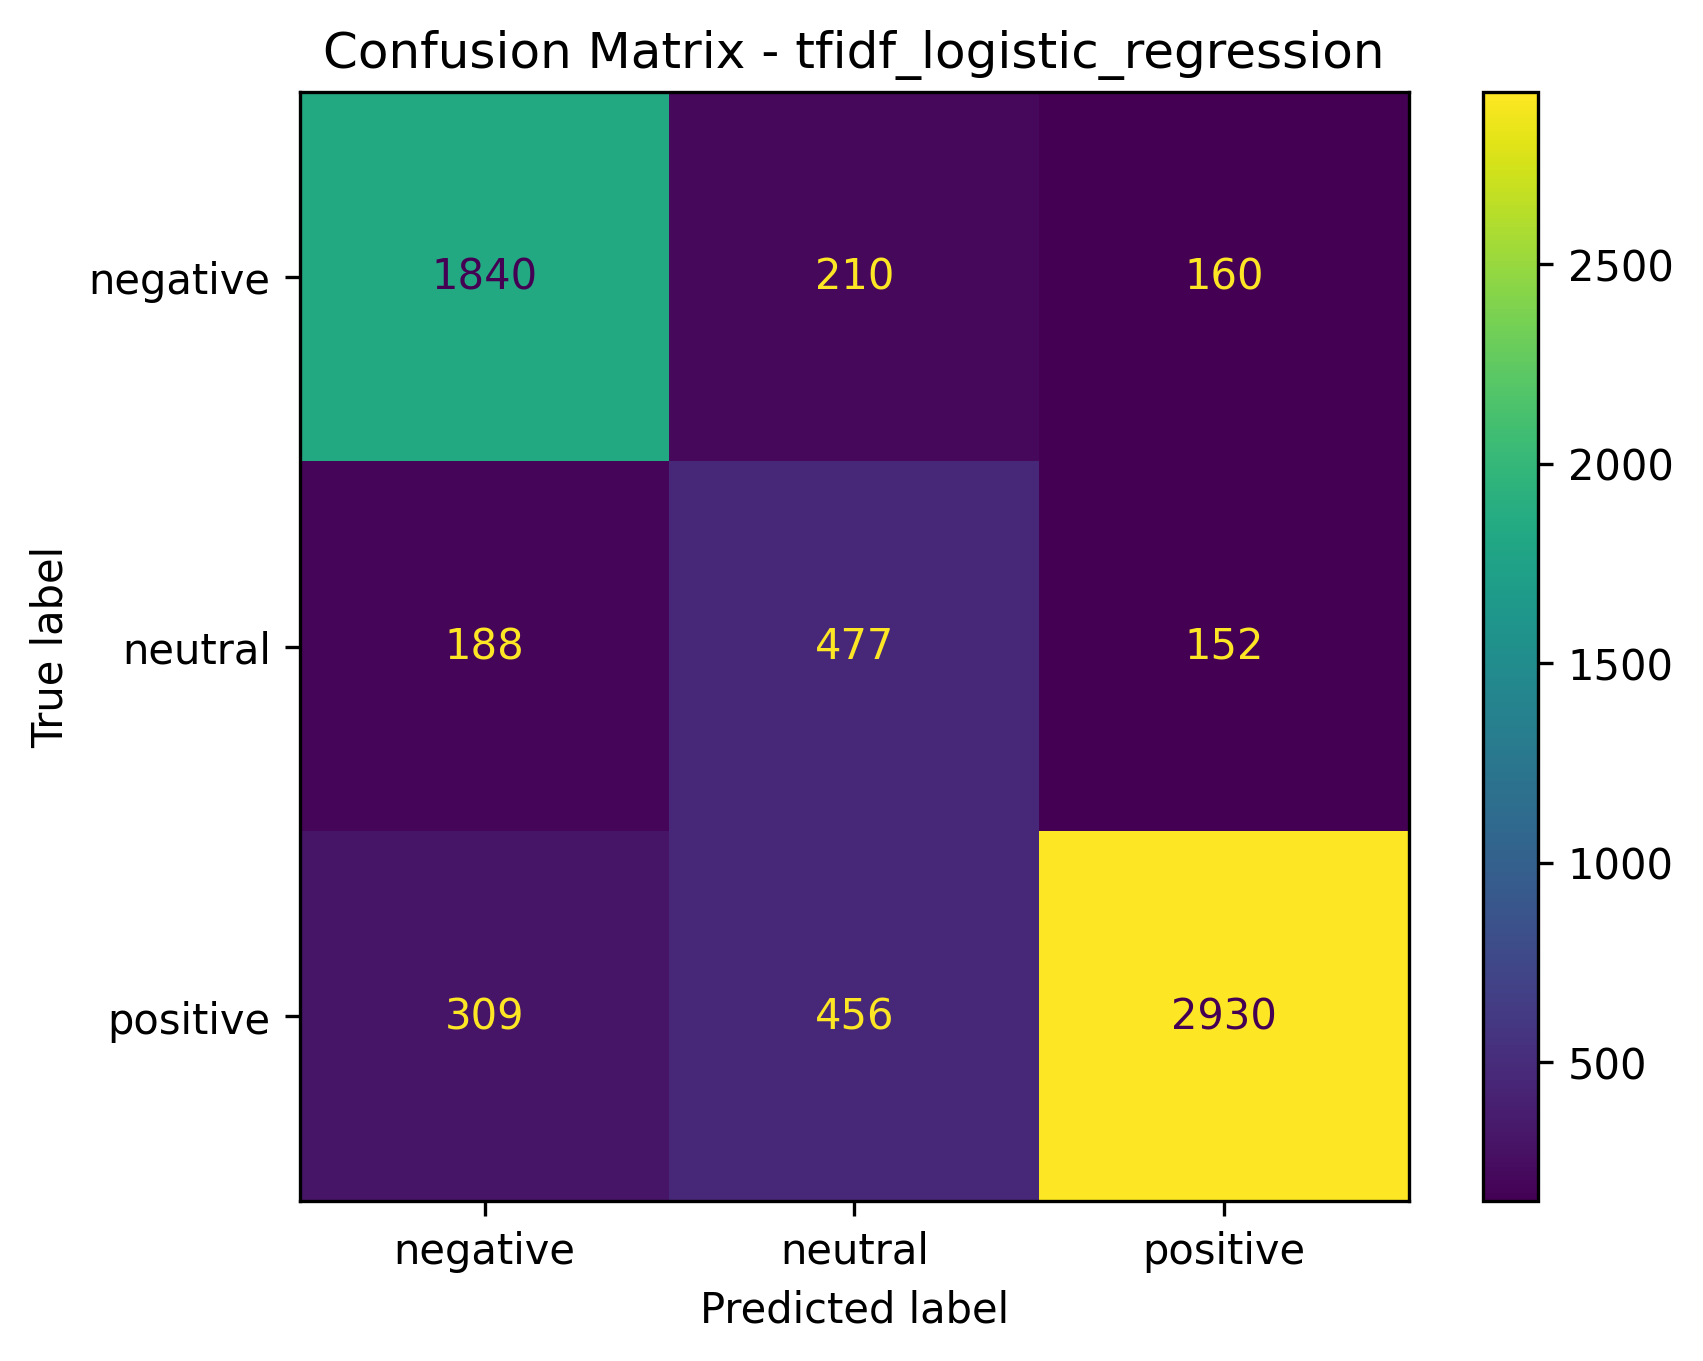

tfidf_linear_svm_confusion_matrix.png


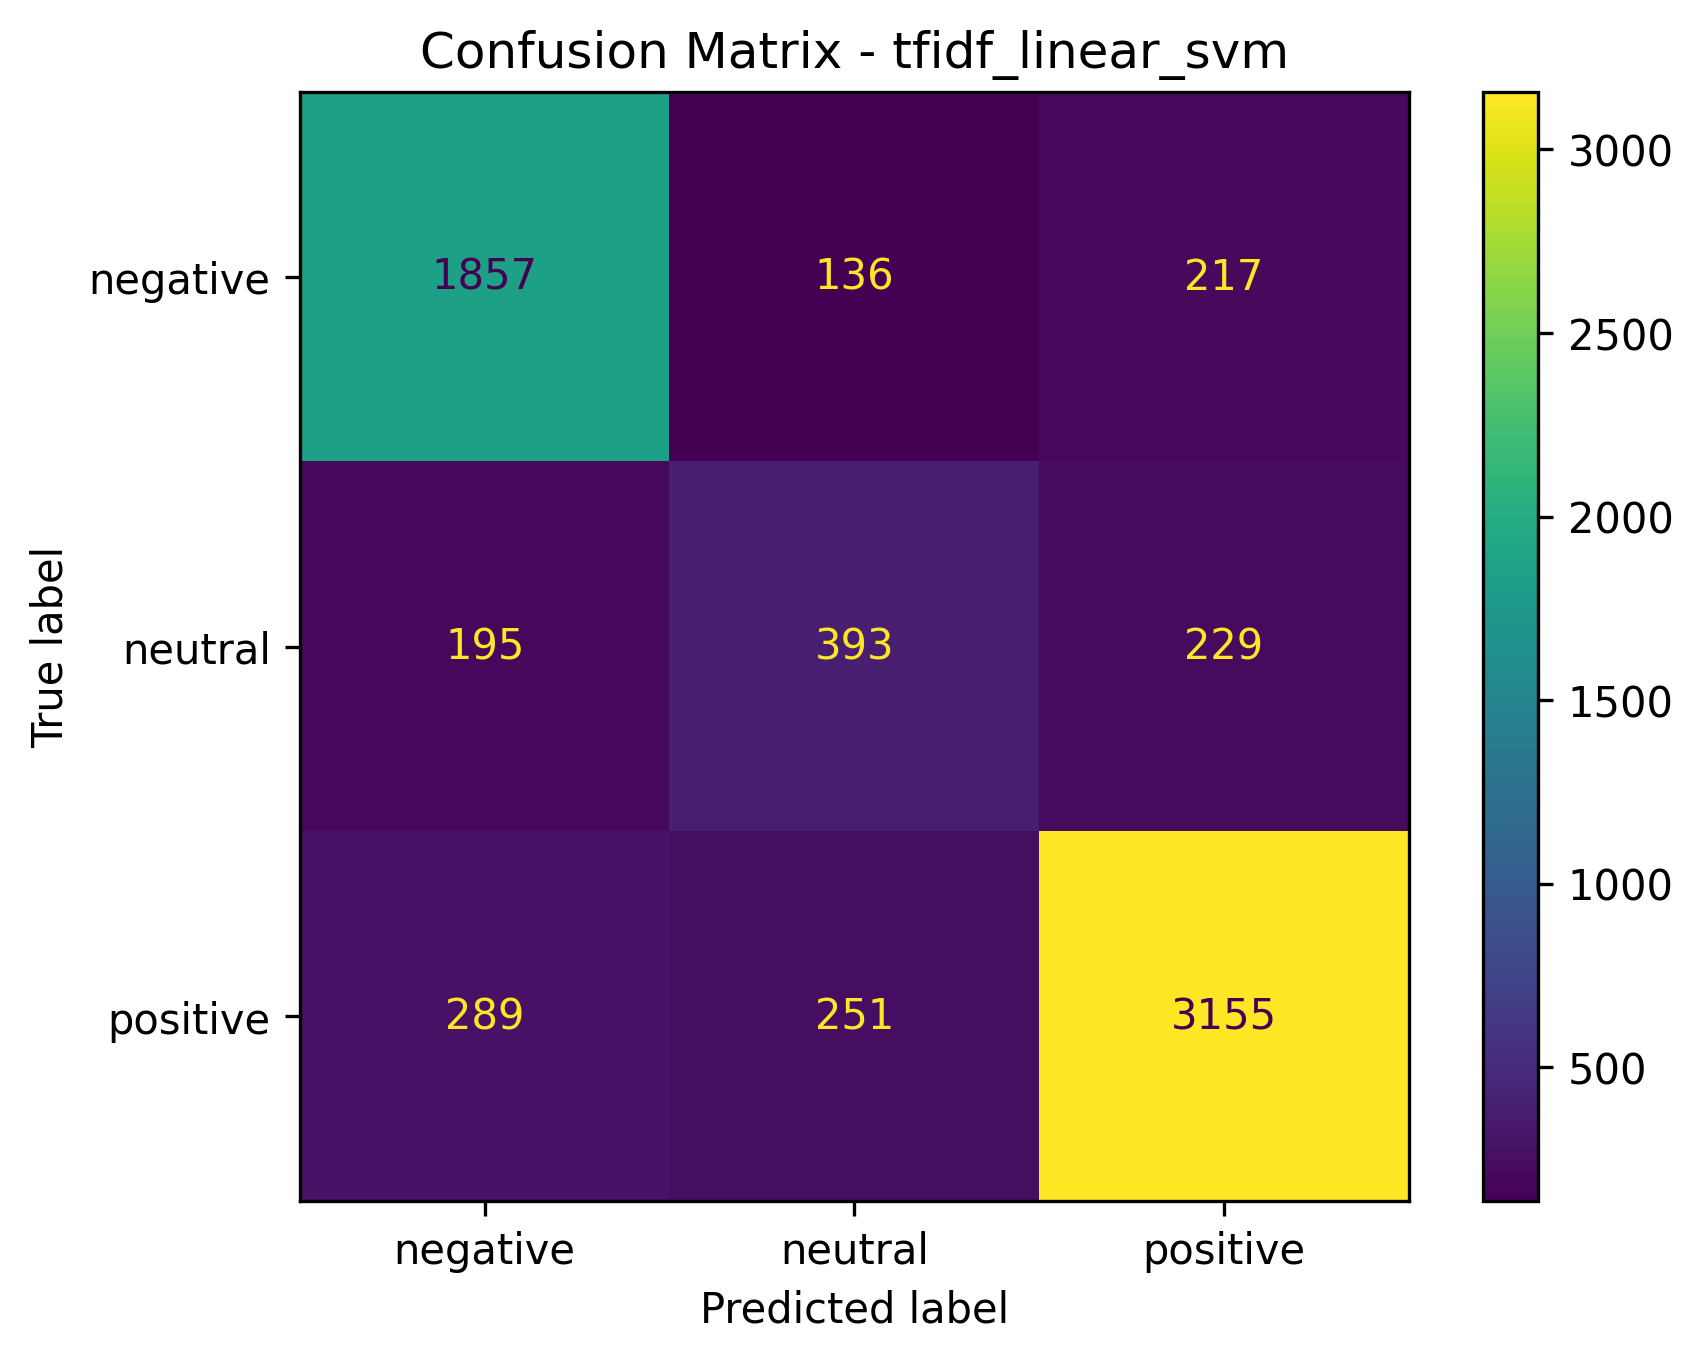

In [6]:
image_files = [
    FIGURE_DIR / "confusion_matrix.png",
    FIGURE_DIR / "tfidf_logistic_regression_confusion_matrix.png",
    FIGURE_DIR / "tfidf_linear_svm_confusion_matrix.png"
]

for img_path in image_files:
    if img_path.exists():
        print(img_path.name)
        display(Image(filename=str(img_path)))
    else:
        print("Không tìm thấy:", img_path)


## 7. Test dự đoán bằng PhoBERT

In [7]:
comment = "Camera chụp đêm rất tệ, ảnh bị mờ và nhiễu."
aspect = "CAMERA"

try:
    from predict import ABSAPredictor
    predictor = ABSAPredictor()
    result = predictor.predict(comment, aspect)
    display(pd.DataFrame([result]))
except Exception as e1:
    try:
        from predict import predict_sentiment
        sentiment, confidence = predict_sentiment(comment, aspect)
        display(pd.DataFrame([{
            "text": comment,
            "aspect": aspect,
            "sentiment": sentiment,
            "confidence": confidence
        }]))
    except Exception as e2:
        print("Không chạy được predict. Kiểm tra src/predict.py")
        print("Lỗi 1:", e1)
        print("Lỗi 2:", e2)


Đang load model từ: F:\phobert-absa-lime-phone-review\models\phobert_absa


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model đã load xong. Device: cpu


,text,aspect,pred_label,confidence,prob_negative,prob_neutral,prob_positive
0,"Camera chụp đêm rất tệ, ảnh bị mờ và nhiễu.",CAMERA,negative,0.991799,0.991799,0.005716,0.002485


## 8. Test giải thích bằng LIME

Đang load model từ: F:\phobert-absa-lime-phone-review\models\phobert_absa


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model và LIME đã load xong. Device: cpu
Dự đoán: negative
Độ tin cậy: 0.9918


,Từ/cụm từ,Trọng số ảnh hưởng
0,tệ,0.100080
1,nhiễu,0.072765
2,bị,0.070902
3,mờ,0.070758
4,rất,0.041057
5,chụp,-0.037334
6,ảnh,-0.036498
7,và,-0.035811
8,đêm,0.011116
9,Camera,-0.010297


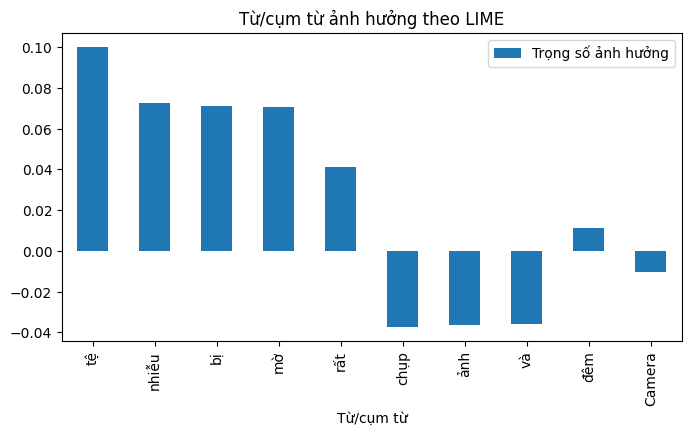

In [8]:
comment = "Camera chụp đêm rất tệ, ảnh bị mờ và nhiễu."
aspect = "CAMERA"

try:
    from lime_explain import ABSALimeExplainer
    explainer = ABSALimeExplainer()
    lime_result = explainer.explain(comment, aspect, num_features=10, num_samples=200)

    print("Dự đoán:", lime_result["pred_label"])
    print("Độ tin cậy:", round(lime_result["confidence"], 4))

    lime_df = pd.DataFrame(lime_result["lime_words"], columns=["Từ/cụm từ", "Trọng số ảnh hưởng"])
    display(lime_df)

    lime_df.set_index("Từ/cụm từ").plot(kind="bar", figsize=(8, 4))
    plt.title("Từ/cụm từ ảnh hưởng theo LIME")
    plt.show()
except Exception as e1:
    try:
        from lime_explain import get_lime_explanation
        html = get_lime_explanation(comment, aspect)
        display(HTML(html))
    except Exception as e2:
        print("Không chạy được LIME. Kiểm tra src/lime_explain.py")
        print("Lỗi 1:", e1)
        print("Lỗi 2:", e2)


## 9. Nhận xét

- PhoBERT là mô hình chính do có khả năng biểu diễn ngữ nghĩa tiếng Việt tốt hơn các mô hình truyền thống.
- TF-IDF + Logistic Regression và TF-IDF + Linear SVM được dùng làm baseline để đối chứng.
- LIME không phải mô hình phân loại mới, mà là kỹ thuật giải thích kết quả dự đoán của PhoBERT.
- Với các bình luận chứa nhiều khía cạnh và cảm xúc trái chiều, mô hình có thể bị ảnh hưởng bởi cảm xúc chung của toàn câu. Đây là hạn chế có thể cải thiện trong tương lai.
